# Sarcasm Detection — NLP Pipeline

**Dataset:** Sarcastic Headlines (sarcastic_headlines.csv)  
**Task:** Binary text classification — detect sarcasm in news headlines  
**Models:** Simple RNN · LSTM · LSTM + Pretrained GloVe Embeddings

---

| Section | Description |
|---------|-------------|
| 1 | Text Preprocessing, Tokenization & Padding |
| 2 | Model Building (RNN / LSTM / LSTM+GloVe) |
| 3 | Training, Evaluation & Visualization |
| 4 | Error Analysis |
| 5 | GUI for Real-Time Prediction (Gradio) |

---
## Section 0 — Install & Import Dependencies

Install required libraries. These commands are needed if running in **Google Colab** where packages may not be pre-installed.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Install required packages (Google Colab)
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install gradio -q
!pip install wordcloud -q

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
# Standard Library
import re
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# Data & Numerics
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem   import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score)

# Deep Learning (Keras / TensorFlow)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping

print('All libraries imported successfully')

All libraries imported successfully


---
## Section 1 Text Preprocessing, Tokenization & Padding

In this section we:
1. **Load** the raw headline dataset
2. **Clean** the text (lowercase → expand contractions → remove noise → stopwords → lemmatize)
3. **Visualise** cleaned data with a word cloud and frequency chart
4. **Tokenize & Pad** sequences for model input

### Step 1 — Load the Dataset

In [ ]:
# Load the sarcastic headlines CSV
df = pd.read_csv('/content/drive/MyDrive/DeepLearning/sarcastic_dataset/sarcastic_headlines.csv')

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())

print('\nClass distribution:')
print(df['is_sarcastic'].value_counts())
print('\nMissing values:')
print(df.isnull().sum())

Dataset shape: (28619, 2)

First 5 rows:


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1



Class distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64

Missing values:
headline        0
is_sarcastic    0
dtype: int64


### Step 2 — Text Cleaning

We apply the following preprocessing pipeline to every headline:

| Step | Operation |
|------|-----------|
| 1 | Lowercase all text |
| 2 | Expand contractions (`don't` → `do not`) |
| 3 | Remove URLs, @mentions, #hashtags |
| 4 | Remove digits and special characters |
| 5 | Remove NLTK English stopwords |
| 6 | Lemmatize remaining tokens |

In [ ]:
# Contraction Map
CONTRACTIONS = {
    "don't": "do not",
    "won't": "will not",
    "can't": "cannot",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "wouldn't": "would not",
    "couldn't": "could not",
    "shouldn't": "should not",
    "it's": "it is",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "i'd": "i would",
    "they're": "they are",
    "they've": "they have",
    "they'll": "they will",
    "we're": "we are",
    "we've": "we have",
    "we'll": "we will",
    "you're": "you are",
    "you've": "you have",
    "you'll": "you will",
    "he's": "he is",
    "she's": "she is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is",
    "let's": "let us",
}

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def expand_contractions(text: str) -> str:
    """Replace contractions with their expanded full forms."""
    for contraction, expanded in CONTRACTIONS.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a single headline string."""
    text = text.lower() # 1. Lowercase
    text = expand_contractions(text) # 2. Expand contractions
    text = re.sub(r'http\S+|www\S+', '', text) # 3a. Remove URLs
    text = re.sub(r'@\w+', '', text) # 3b. Remove @mentions
    text = re.sub(r'#\w+', '', text) # 3c. Remove #hashtags
    text = re.sub(r'\d+', '', text) # 4a. Remove digits
    text = re.sub(r'[^a-z\s]', '', text) # 4b. Remove special chars
    text = text.strip()
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words] # 5. Stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # 6. Lemmatize
    return ' '.join(tokens)

# Apply to all rows
df['cleaned'] = df['headline'].apply(clean_text)

print('Cleaning complete ')
print('\nSample before / after:')
display(df[['headline', 'cleaned']].head(8))

Cleaning complete 

Sample before / after:


,headline,cleaned
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...
5,my white inheritance,white inheritance
6,5 ways to file your taxes with less stress,way file tax less stress
7,richard branson's global-warming donation near...,richard bransons globalwarming donation nearly...


### Step 3 — Visualise Cleaned Data

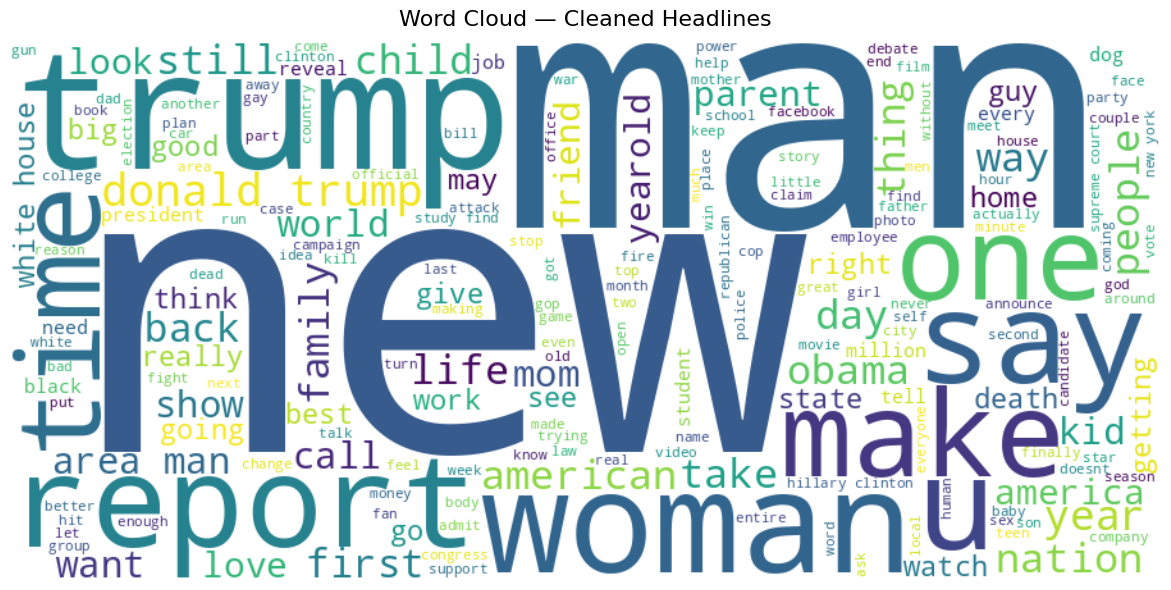

In [ ]:
# Word Cloud
all_text = ' '.join(df['cleaned'])
wc = WordCloud(width=900, height=420, background_color='white', max_words=200, colormap='viridis').generate(all_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Cleaned Headlines', fontsize=16, pad=12)
plt.tight_layout()
plt.show()

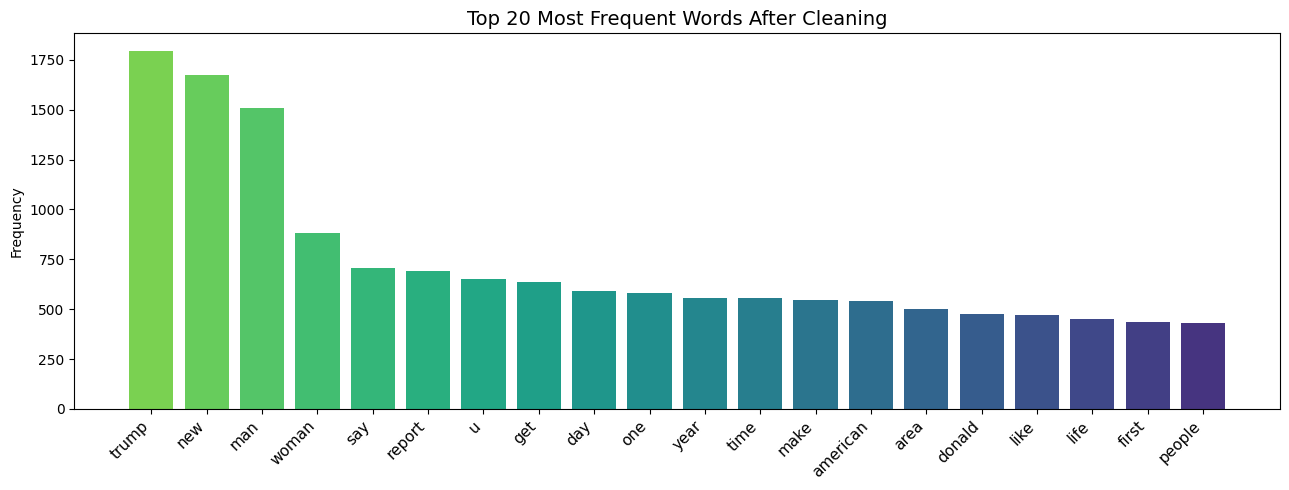

In [ ]:
# Top 20 Most Frequent Words
word_counts = Counter(all_text.split())
top20 = word_counts.most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(13, 5))
bars = plt.bar(words, counts, color=plt.cm.viridis_r(np.linspace(0.2, 0.85, 20)))
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.title('Top 20 Most Frequent Words After Cleaning', fontsize=14)
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Step 4 — Tokenization & Sequence Padding

- **Train/Test split:** 80 % training · 20 % testing (stratified)
- **Tokenizer:** Keras `Tokenizer` fit only on training data (no data leakage)
- **Padding length:** 95th percentile of training sequence lengths (avoids padding to extreme outliers)

In [ ]:
# Train / Test Split
X = df['cleaned'].values
y = df['is_sarcastic'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples : {len(X_train):,}')
print(f'Testing  samples : {len(X_test):,}')

Training samples : 22,895
Testing  samples : 5,724


In [ ]:
# Keras Tokenizer
MAX_WORDS = 20_000 # Max vocabulary size

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train) # Fit on training data ONLY

word_index = tokenizer.word_index
vocab_size  = min(MAX_WORDS, len(word_index)) + 1
print(f'Vocabulary size : {vocab_size:,}')

# Convert text → integer sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length
seq_lengths = [len(s) for s in train_sequences]
MAX_LEN = int(np.percentile(seq_lengths, 95))
print(f'Padding length (95th percentile) : {MAX_LEN} tokens')

# Pad / truncate sequences to MAX_LEN
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'\nX_train shape : {X_train_pad.shape}')
print(f'X_test  shape : {X_test_pad.shape}')

Vocabulary size : 20,001
Padding length (95th percentile) : 11 tokens

X_train shape : (22895, 11)
X_test  shape : (5724, 11)


---
## Section 2 — Model Building

We build **three architectures** for comparison:

| Model | Embedding | Recurrent Layer |
|-------|-----------|------------------|
| 1 | Trainable Embedding | **SimpleRNN** |
| 2 | Trainable Embedding | **LSTM** |
| 3 | Pretrained **GloVe** (frozen) | **LSTM** |

### Model 1 — Simple RNN with Trainable Embedding

In [ ]:
EMBEDDING_DIM = 64 # Embedding output dimension for Models 1 & 2

model1 = Sequential(name='SimpleRNN_Model')
model1.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)) # Trainable embedding layer
model1.add(SimpleRNN(64, return_sequences=False))
model1.add(Dropout(0.3))
model1.add(Dense(1, activation='sigmoid')) # Binary output
model1.build(input_shape=(None, MAX_LEN))
model1.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 11, 64)         │     1,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,385 (4.91 MB)

 Trainable params: 1,288,385 (4.91 MB)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [ ]:
model2 = Sequential(name='LSTM_Model')
model2.add(Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN)) # Trainable embedding layer
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation='sigmoid')) # Binary output
model2.build(input_shape=(None, MAX_LEN))
model2.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 11, 64)         │     1,280,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,153 (5.01 MB)

 Trainable params: 1,313,153 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pretrained GloVe Embeddings

In [ ]:
# Download Pretrained GloVe via Gensim
import gensim.downloader as api

print('Downloading glove-wiki-gigaword-50 (≈70 MB, cached after first run)...')
embedding_model = api.load('glove-wiki-gigaword-50') # 50-dimensional GloVe
print('GloVe loaded')

GloVe loaded


In [ ]:
# Build the GloVe Embedding Matrix
GLOVE_DIM = 50 # Must match the downloaded model dimension

embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))
found, not_found = 0, 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word] # Use pretrained vector
        found += 1
    else:
        not_found += 1 # Zero vector for OOV

print(f'Words found in GloVe: {found:,}')
print(f'Words NOT found in GloVe: {not_found:,}')
print(f'Embedding matrix shape: {embedding_matrix.shape}')

Words found in GloVe: 17,739
Words NOT found in GloVe: 2,261
Embedding matrix shape: (20001, 50)


In [ ]:
# Build LSTM Model with Frozen GloVe Embedding Layer
model3 = Sequential(name='LSTM_GloVe_Model')
model3.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix], # Initialise with GloVe vectors
    input_length=MAX_LEN,
    trainable=True # Freeze — set True to fine-tune
))
model3.add(LSTM(64, return_sequences=False))
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid')) # Binary output
model3.build(input_shape=(None, MAX_LEN))
model3.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 11, 50)         │     1,000,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,029,555 (3.93 MB)

 Trainable params: 1,029,555 (3.93 MB)

 Non-trainable params: 0 (0.00 B)

---
## Section 3 — Model Training & Evaluation

**Compile configuration:**
- **Loss:** `binary_crossentropy` — appropriate for binary classification
- **Optimizer:** `adam` — adaptive learning rate, well-suited for NLP
- **Metric:** `accuracy`

**Training:** Up to 15 epochs with `EarlyStopping` (patience = 3, monitors `val_loss`)

In [ ]:
# Compile All Three Models
for model in [model1, model2, model3]:
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

# EarlyStopping: stop when val_loss stops improving; restore best weights
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 15
BATCH_SIZE = 64

print('Models compiled')

Models compiled


### Train Model 1 — Simple RNN

In [ ]:
history1 = model1.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.7465 - loss: 0.4976 - val_accuracy: 0.8157 - val_loss: 0.4164
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9274 - loss: 0.1931 - val_accuracy: 0.7991 - val_loss: 0.4921
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9804 - loss: 0.0599 - val_accuracy: 0.7921 - val_loss: 0.7022
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9921 - loss: 0.0240 - val_accuracy: 0.7672 - val_loss: 0.8970
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


### Train Model 2 — LSTM

In [ ]:
history2 = model2.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.7454 - loss: 0.5012 - val_accuracy: 0.8100 - val_loss: 0.4299
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8854 - loss: 0.2789 - val_accuracy: 0.7917 - val_loss: 0.4609
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9327 - loss: 0.1788 - val_accuracy: 0.7838 - val_loss: 0.5392
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


### Train Model 3 — LSTM + GloVe

In [ ]:
history3 = model3.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7205 - loss: 0.5441 - val_accuracy: 0.7712 - val_loss: 0.4683
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.8314 - loss: 0.3786 - val_accuracy: 0.8070 - val_loss: 0.4028
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8960 - loss: 0.2575 - val_accuracy: 0.8183 - val_loss: 0.4133
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9405 - loss: 0.1609 - val_accuracy: 0.8170 - val_loss: 0.4412
Epoch 5/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.9633 - loss: 0.1028 - val_accuracy: 0.8052 - val_loss: 0.5926
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


### Training & Validation Curves (Per Model)

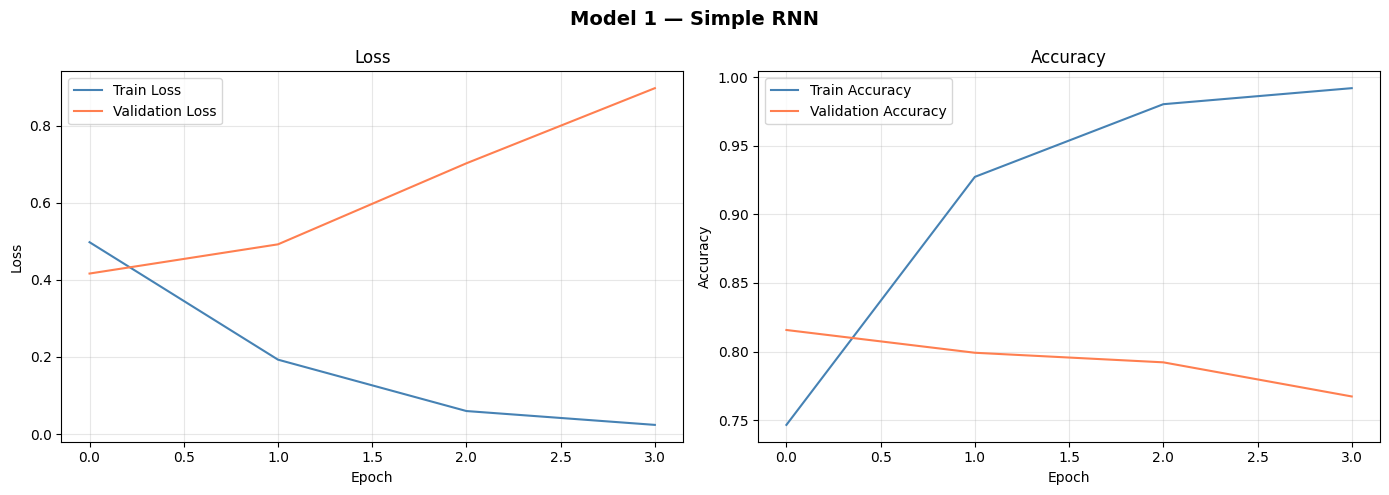

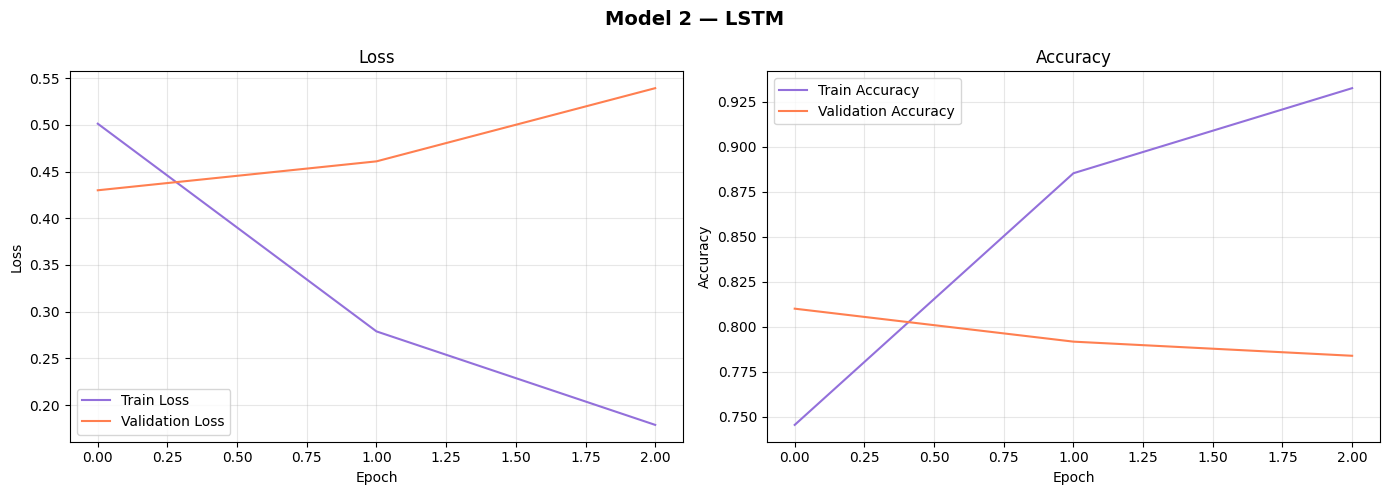

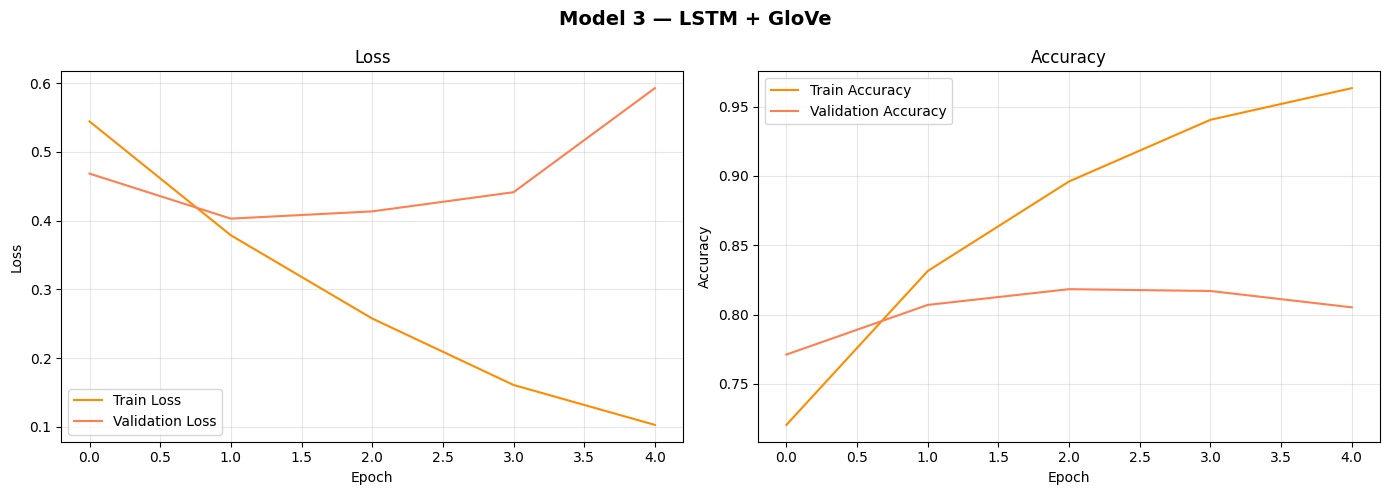

In [ ]:
def plot_history(history, model_name, color='steelblue'):
    """Plot training vs. validation loss and accuracy for a single model."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(model_name, fontsize=14, fontweight='bold')

    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color=color)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='coral')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', color=color)
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history1, 'Model 1 — Simple RNN', color='steelblue')
plot_history(history2, 'Model 2 — LSTM', color='mediumpurple')
plot_history(history3, 'Model 3 — LSTM + GloVe', color='darkorange')

### Model Comparison Plot

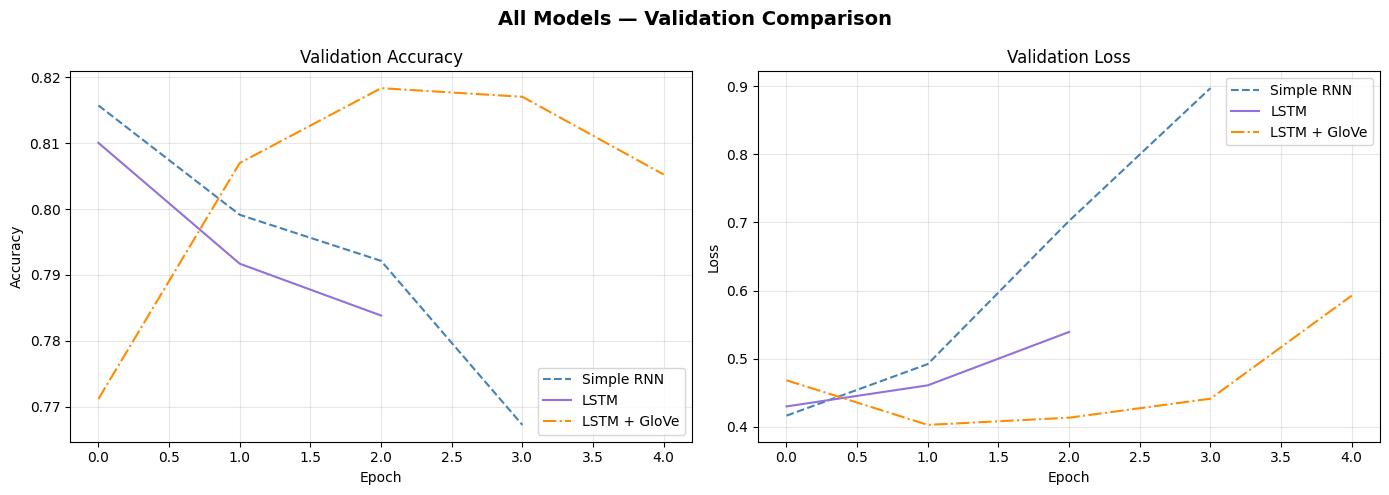

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Models — Validation Comparison', fontsize=14, fontweight='bold')

# Validation Accuracy
axes[0].plot(history1.history['val_accuracy'], label='Simple RNN', linestyle='--', color='steelblue')
axes[0].plot(history2.history['val_accuracy'], label='LSTM', linestyle='-', color='mediumpurple')
axes[0].plot(history3.history['val_accuracy'], label='LSTM + GloVe', linestyle='-.', color='darkorange')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation Loss
axes[1].plot(history1.history['val_loss'], label='Simple RNN', linestyle='--', color='steelblue')
axes[1].plot(history2.history['val_loss'], label='LSTM', linestyle='-', color='mediumpurple')
axes[1].plot(history3.history['val_loss'], label='LSTM + GloVe', linestyle='-.', color='darkorange')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Evaluate on Test Set

Each model is evaluated on:
- **Accuracy** — overall correct predictions
- **Classification Report** — precision, recall, F1 per class
- **Confusion Matrix** — visualised as a heatmap

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate a trained model and display all metrics."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    print(f'\n{"="*55}')
    print(f'  {model_name}  —  Test Accuracy: {acc:.4f} ({acc*100:.2f}%)')
    print(f'{"="*55}')
    print(classification_report(y_test, y_pred, target_names=['Not Sarcastic', 'Sarcastic']))

    # Confusion Matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Sarcastic', 'Sarcastic'], yticklabels=['Not Sarcastic', 'Sarcastic'])
    plt.title(f'Confusion Matrix — {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return y_pred, y_prob


  Simple RNN  —  Test Accuracy: 0.8033 (80.33%)
               precision    recall  f1-score   support

Not Sarcastic       0.81      0.82      0.81      2997
    Sarcastic       0.80      0.78      0.79      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



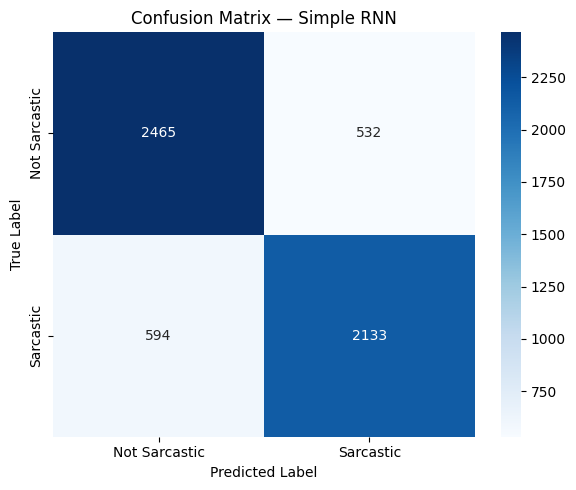


  LSTM  —  Test Accuracy: 0.7911 (79.11%)
               precision    recall  f1-score   support

Not Sarcastic       0.77      0.86      0.81      2997
    Sarcastic       0.82      0.72      0.77      2727

     accuracy                           0.79      5724
    macro avg       0.80      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



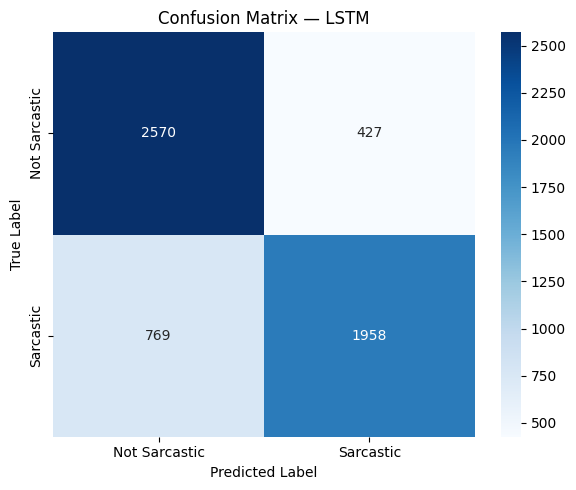


  LSTM + GloVe  —  Test Accuracy: 0.8187 (81.87%)
               precision    recall  f1-score   support

Not Sarcastic       0.81      0.86      0.83      2997
    Sarcastic       0.83      0.77      0.80      2727

     accuracy                           0.82      5724
    macro avg       0.82      0.82      0.82      5724
 weighted avg       0.82      0.82      0.82      5724



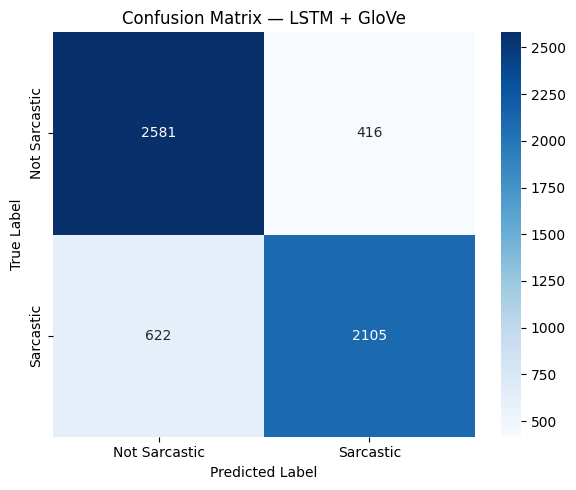

In [ ]:
y_pred1, y_prob1 = evaluate_model(model1, X_test_pad, y_test, 'Simple RNN')
y_pred2, y_prob2 = evaluate_model(model2, X_test_pad, y_test, 'LSTM')
y_pred3, y_prob3 = evaluate_model(model3, X_test_pad, y_test, 'LSTM + GloVe')

---
## Section 4 — Error Analysis

We analyse **misclassified examples** from **Model 3 (LSTM)** — the strongest purely-learned model.

In [ ]:
# Find Misclassified Examples for LSTM GloVe
misclassified_idx = np.where(y_pred3 != y_test)[0]
error_rate = len(misclassified_idx) / len(y_test) * 100

print(f'Total misclassified by LSTM GloVe: {len(misclassified_idx):,}')
print(f'Error rate: {error_rate:.2f}%')

print('\n--- 3 Sample Misclassified Examples ---')
for rank, idx in enumerate(misclassified_idx[:3], 1):
    actual = 'Sarcastic' if y_test[idx] == 1 else 'Not Sarcastic'
    predicted = 'Sarcastic' if y_pred3[idx] == 1 else 'Not Sarcastic'
    conf = y_prob3[idx] if y_pred3[idx] == 1 else 1 - y_prob3[idx]

    print(f'\n  Example {rank}')
    print(f' Original  : {X_test[idx]}')
    print(f' True label: {actual}')
    print(f' Predicted : {predicted} (confidence: {conf:.2%})')

Total misclassified by LSTM GloVe: 1,038
Error rate: 18.13%

--- 3 Sample Misclassified Examples ---

  Example 1
 Original  : group christie campaign deserter found forest
 True label: Sarcastic
 Predicted : Not Sarcastic (confidence: 64.98%)

  Example 2
 Original  : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
 True label: Sarcastic
 Predicted : Not Sarcastic (confidence: 97.23%)

  Example 3
 Original  : rex tillerson call report ouster laughable
 True label: Not Sarcastic
 Predicted : Sarcastic (confidence: 90.43%)


  HARDWARE SUMMARY
  GPU  : GPU info unavailable
  CPU  : 2 logical cores
  RAM  : 12.7 GB total
  RAM available: 9.9 GB
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.9226 - loss: 0.1967 - val_accuracy: 0.7934 - val_loss: 0.4873
Epoch 2/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.9792 - loss: 0.0597 - val_accuracy: 0.7856 - val_loss: 0.6722
Epoch 3/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9927 - loss: 0.0236 - val_accuracy: 0.7882 - val_loss: 0.8061
Epoch 4/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9973 - loss: 0.0090 - val_accuracy: 0.7891 - val_loss: 0.8950

  Simple RNN
  Epochs run : 4 / 15 (early stopping)
  Total time : 32.29 sec
  Time per epoch : 8.07 sec
  RAM before : 1710.3 MB
  RAM after : 1731.6 MB
  RAM used by model : 21.2 MB
  GPU before train : GPU info unavailable
  GPU after train : GPU info unavailable
Epoch 1/15
322/322 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8880 - loss: 0.2735 - val_a

,Model,Epochs Run,Total Time (s),Time/Epoch (s),RAM Used (MB),GPU Info
0,Simple RNN,4,32.29,8.07,21.2,GPU info unavailable
1,LSTM,4,33.57,8.39,-9.0,GPU info unavailable
2,LSTM + GloVe,4,36.38,9.10,7.9,GPU info unavailable


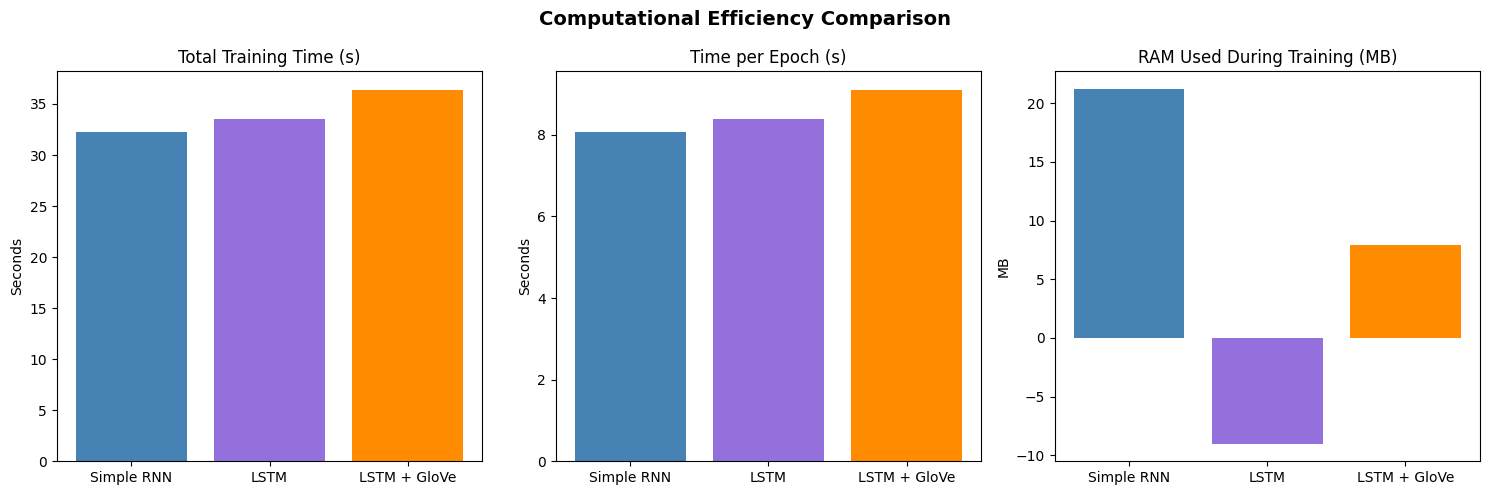

In [ ]:
import time
import psutil
import os
import subprocess
import pandas as pd

# Helper: get GPU memory info
def get_gpu_memory():
    try:
        result = subprocess.check_output(
            ['nvidia-smi', '--query-gpu=name,memory.used,memory.total,utilization.gpu',
             '--format=csv,noheader,nounits'],
            encoding='utf-8'
        )
        name, used, total, util = result.strip().split(', ')
        return f"{name} | Used: {used} MB / {total} MB | GPU Util: {util}%"
    except:
        return "GPU info unavailable"

# Helper: train with timing + memory tracking
def train_with_profiling(model, X_train, y_train, model_name, epochs=15, batch_size=64):
    early_stop = EarlyStopping(monitor='val_loss', patience=3,
                               restore_best_weights=True, verbose=0)

    process = psutil.Process(os.getpid())
    ram_before = process.memory_info().rss / (1024 ** 2)  # MB
    gpu_before = get_gpu_memory()

    start = time.time()
    history = model.fit(
        X_train, y_train,
        validation_split=0.1,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )
    elapsed = time.time() - start

    ram_after = process.memory_info().rss / (1024 ** 2)
    gpu_after = get_gpu_memory()
    epochs_run = len(history.history['loss'])

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Epochs run : {epochs_run} / {epochs} (early stopping)")
    print(f"  Total time : {elapsed:.2f} sec")
    print(f"  Time per epoch : {elapsed/epochs_run:.2f} sec")
    print(f"  RAM before : {ram_before:.1f} MB")
    print(f"  RAM after : {ram_after:.1f} MB")
    print(f"  RAM used by model : {ram_after - ram_before:.1f} MB")
    print(f"  GPU before train : {gpu_before}")
    print(f"  GPU after train : {gpu_after}")

    return history, {
        'Model': model_name,
        'Epochs Run': epochs_run,
        'Total Time (s)': round(elapsed, 2),
        'Time/Epoch (s)': round(elapsed / epochs_run, 2),
        'RAM Used (MB)': round(ram_after - ram_before, 1),
        'GPU Info': gpu_after
    }

# Print GPU & Hardware Info First
print("=" * 55)
print("  HARDWARE SUMMARY")
print("=" * 55)
print(f"  GPU  : {get_gpu_memory()}")
print(f"  CPU  : {psutil.cpu_count(logical=True)} logical cores")
print(f"  RAM  : {psutil.virtual_memory().total / (1024**3):.1f} GB total")
print(f"  RAM available: {psutil.virtual_memory().available / (1024**3):.1f} GB")

# Train All 3 Models with Profiling
history1, stats1 = train_with_profiling(model1, X_train_pad, y_train, 'Simple RNN')
history2, stats2 = train_with_profiling(model2, X_train_pad, y_train, 'LSTM')
history3, stats3 = train_with_profiling(model3, X_train_pad, y_train, 'LSTM + GloVe')

# Summary Comparison Table
summary_df = pd.DataFrame([stats1, stats2, stats3])
print("\n\nCOMPUTATIONAL EFFICIENCY SUMMARY")
display(summary_df)

# Bar Chart: Training Time Comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Computational Efficiency Comparison', fontsize=14, fontweight='bold')

models = [s['Model'] for s in [stats1, stats2, stats3]]
colors = ['steelblue', 'mediumpurple', 'darkorange']

axes[0].bar(models, [s['Total Time (s)'] for s in [stats1, stats2, stats3]], color=colors)
axes[0].set_title('Total Training Time (s)')
axes[0].set_ylabel('Seconds')

axes[1].bar(models, [s['Time/Epoch (s)'] for s in [stats1, stats2, stats3]], color=colors)
axes[1].set_title('Time per Epoch (s)')
axes[1].set_ylabel('Seconds')

axes[2].bar(models, [s['RAM Used (MB)'] for s in [stats1, stats2, stats3]], color=colors)
axes[2].set_title('RAM Used During Training (MB)')
axes[2].set_ylabel('MB')

plt.tight_layout()
plt.show()

### Model Complexity vs. Performance

| Model | Strength | Weakness |
|-------|----------|----------|
| **Simple RNN** | Fast to train | Vanishing gradients; forgets early tokens |
| **LSTM** | Captures long-range dependencies | More parameters; slower training |
| **LSTM + GloVe** | Richer semantic initialisation for rare words | Frozen embeddings may miss domain nuance |

### Possible Reasons for Errors

1. **Implicit / contextual sarcasm** — Headlines like *"Great job, politicians!"* require world knowledge the model hasn't learnt from surface tokens alone.
2. **Domain-specific irony** — Mixing factual reporting with ironic framing (e.g., *"experts baffled by obvious thing"*) can fool bag-of-words-style representations.
3. **Short / ambiguous headlines** — Brief headlines lack sufficient context for the model to determine tone.
4. **OOV words** — Words absent from the GloVe vocabulary default to zero vectors, losing semantic signal.

### Suggested Improvements

- **Bidirectional LSTM** — reads the sequence in both directions, capturing richer context.
- **Attention mechanism** — focuses model on the most sentiment-bearing tokens.
- **Transformer fine-tuning** — fine-tune BERT / RoBERTa on this dataset for state-of-the-art results.
- **Higher-dimensional GloVe** — try 100d or 300d vectors for richer representations.
- **Data augmentation** — synonym replacement or back-translation to improve generalisation.

---
## Section 5 — GUI for Real-Time Prediction (Gradio)

A simple interactive UI: enter any headline and get sarcasm predictions from all three models instantly.

> In **Google Colab**, set `share=True` to get a public link.

In [ ]:
import gradio as gr

def predict_sarcasm(headline_text: str) -> str:
    """Preprocess a raw headline and return predictions from all 3 models."""
    cleaned = clean_text(headline_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    prob1 = model1.predict(padded, verbose=0)[0][0]
    prob2 = model2.predict(padded, verbose=0)[0][0]
    prob3 = model3.predict(padded, verbose=0)[0][0]

    def label(prob):
        tag = '**SARCASTIC**' if prob >= 0.5 else '**Not Sarcastic**'
        return f'{tag} — confidence: {prob:.2%}'

    return (
        f'**Simple RNN** : {label(prob1)}\n\n'
        f'**LSTM** : {label(prob2)}\n\n'
        f'**LSTM + GloVe**  : {label(prob3)}'
    )

iface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(
        lines=2,
        placeholder='Enter a news headline here...',
        label='Headline'
    ),
    outputs=gr.Markdown(label='Prediction'),
    title='Sarcasm Detector',
    description=(
        'Enter any news headline and get real-time sarcasm predictions '
        'from three deep learning models: Simple RNN, LSTM, and LSTM + GloVe.'
    ),
    examples=[
        ['Scientists discover that exercise is good for health'],
        ['Area man achieves nothing, wins Nobel Prize'],
        ['Government announces plan to fix everything by next Tuesday'],
        ['Local weather continues to be weather'],
    ],
    theme=gr.themes.Soft()
)

iface.launch(share=True)   # share=True for a public Colab link

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://04f882e9adeebebf46.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
